# Analysis of finer sweep over region of interest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

In [3]:
df = pd.read_csv("summary.csv")

In [4]:
df.head()

,c10_equiv_abs,c10_imping_rate,c10_mc_hits,c11_equiv_abs,c11_imping_rate,c11_mc_hits,c12_equiv_abs,c12_imping_rate,c12_mc_hits,c13_equiv_abs,...,deflector_imping_rate,deflector_mc_hits,plate_back_equiv_abs,plate_back_imping_rate,plate_back_mc_hits,plate_front_equiv_abs,plate_front_imping_rate,plate_front_mc_hits,total_des,error
0,0.0,3.957072e+18,3276.0,0.0,3.981230e+18,3296.0,0.0,4.059744e+18,3361.0,0.0,...,6.873885e+18,273226.0,9075.0,4.166204e+18,9075.0,50774.0,2.330963e+19,50774.0,100000.0,NaN
1,0.0,3.761393e+18,3114.0,0.0,3.662345e+18,3032.0,0.0,3.819372e+18,3162.0,0.0,...,6.804398e+18,270464.0,8907.0,4.089078e+18,8907.0,50306.0,2.309477e+19,50306.0,100000.0,NaN
2,0.0,3.524645e+18,2918.0,0.0,3.449755e+18,2856.0,0.0,3.518606e+18,2913.0,0.0,...,6.704419e+18,266490.0,8537.0,3.919216e+18,8537.0,50073.0,2.298781e+19,50073.0,100000.0,NaN
3,0.0,3.341045e+18,2766.0,0.0,3.308431e+18,2739.0,0.0,3.322926e+18,2751.0,0.0,...,6.593345e+18,262075.0,7889.0,3.621728e+18,7889.0,49899.0,2.290793e+19,49899.0,100000.0,NaN
4,0.0,3.156236e+18,2613.0,0.0,3.001625e+18,2485.0,0.0,3.193681e+18,2644.0,0.0,...,6.537670e+18,259862.0,7532.0,3.457835e+18,7532.0,49081.0,2.253239e+19,49081.0,100000.0,NaN


Text(0.5, 0, 'Trial Number')

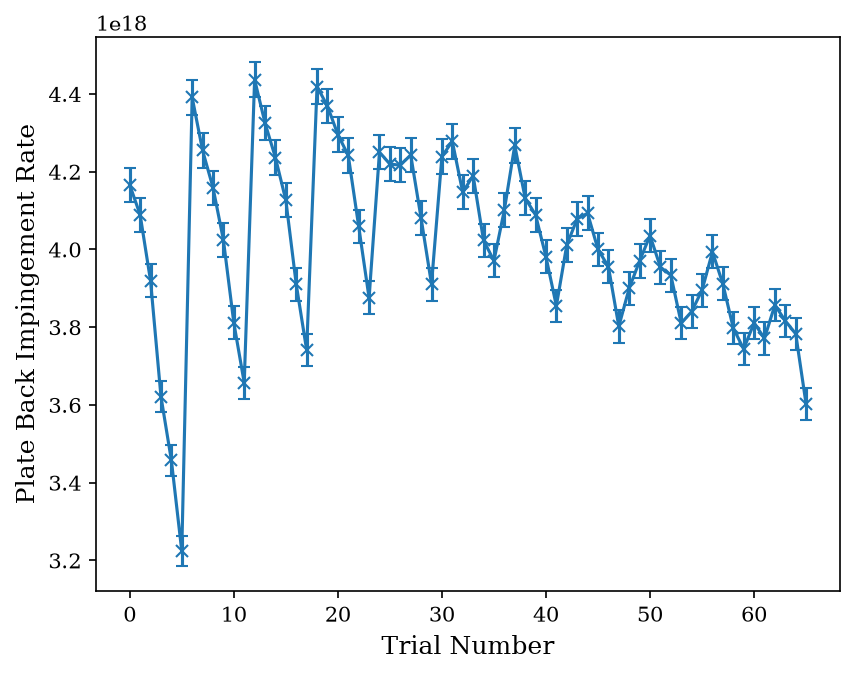

In [10]:
plt.errorbar(y=df['plate_back_imping_rate'], x = np.arange(len(df)), yerr=df['plate_back_imping_rate']/np.sqrt(df['plate_back_mc_hits']), fmt='x-',capsize=3, label='Plate Back Impingement Rate')

plt.ylabel('Plate Back Impingement Rate')
plt.xlabel('Trial Number')

### Generate sweep positions

Could get from run_index.csv but quicker to just replicate here

In [13]:
dist = []

plate_dist = 0
cone_dist = 0


#construct plate and distance pattern
for i in range(0, 11):
    cone_dist = plate_dist - 0.25
    for i in range(0, 6):
        dist.append([round(plate_dist, 2), round(cone_dist, 2)])
        cone_dist += 0.1

    cone_dist = -0.25
    plate_dist += 0.2

print(dist)


[[0, -0.25], [0, -0.15], [0, -0.05], [0, 0.05], [0, 0.15], [0, 0.25], [0.2, -0.05], [0.2, 0.05], [0.2, 0.15], [0.2, 0.25], [0.2, 0.35], [0.2, 0.45], [0.4, 0.15], [0.4, 0.25], [0.4, 0.35], [0.4, 0.45], [0.4, 0.55], [0.4, 0.65], [0.6, 0.35], [0.6, 0.45], [0.6, 0.55], [0.6, 0.65], [0.6, 0.75], [0.6, 0.85], [0.8, 0.55], [0.8, 0.65], [0.8, 0.75], [0.8, 0.85], [0.8, 0.95], [0.8, 1.05], [1.0, 0.75], [1.0, 0.85], [1.0, 0.95], [1.0, 1.05], [1.0, 1.15], [1.0, 1.25], [1.2, 0.95], [1.2, 1.05], [1.2, 1.15], [1.2, 1.25], [1.2, 1.35], [1.2, 1.45], [1.4, 1.15], [1.4, 1.25], [1.4, 1.35], [1.4, 1.45], [1.4, 1.55], [1.4, 1.65], [1.6, 1.35], [1.6, 1.45], [1.6, 1.55], [1.6, 1.65], [1.6, 1.75], [1.6, 1.85], [1.8, 1.55], [1.8, 1.65], [1.8, 1.75], [1.8, 1.85], [1.8, 1.95], [1.8, 2.05], [2.0, 1.75], [2.0, 1.85], [2.0, 1.95], [2.0, 2.05], [2.0, 2.15], [2.0, 2.25]]


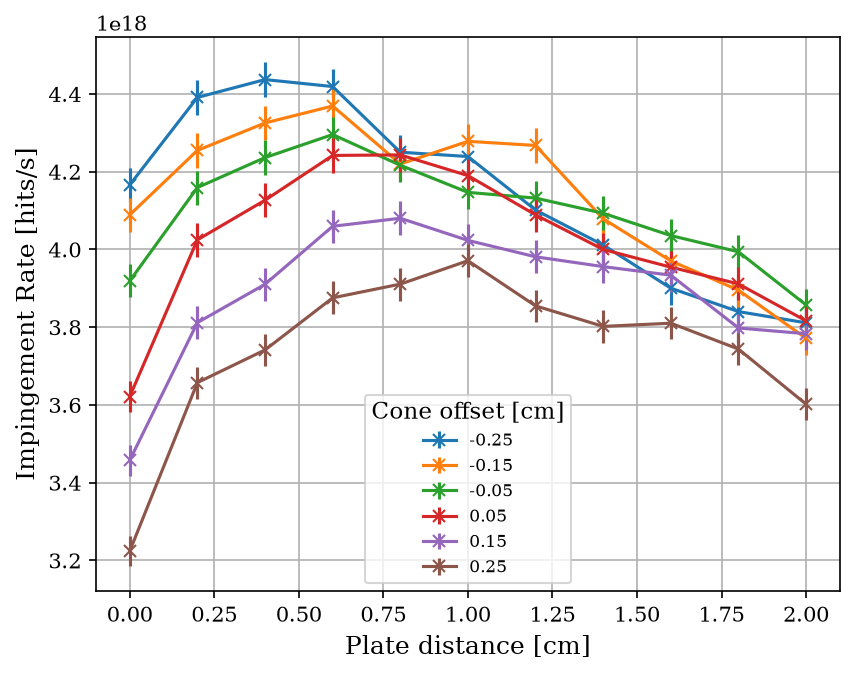

In [18]:
dist = np.array(dist)
intensity = df['plate_back_imping_rate'].to_numpy()

plate = dist[:, 0]
cone = dist[:, 1]
offset = np.round(cone - plate, 2)

fig, ax = plt.subplots()

for o in np.unique(offset):
    mask = offset == o
    order = np.argsort(plate[mask])
    ax.errorbar(plate[mask][order], intensity[mask][order], yerr=intensity[mask][order]/np.sqrt(df["plate_back_mc_hits"][mask]), fmt="x-", label=f'{o}')



ax.set_xlabel('Plate distance [cm]')
ax.set_ylabel('Impingement Rate [hits/s]')
ax.legend(title='Cone offset [cm]',loc="best", fontsize=8)
ax.grid()
plt.savefig("cone_plate_fine_sweep.png", dpi=300, bbox_inches='tight')



### Comments

- Need to run for more desorptions as statistical fluctuations dominate at this finer structure
- -0.25cm cone offset seems to be the best? maybe should explore cone closer to this?